# 1. IMPORT LIBRARIES

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, auc
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 2. Load data

In [4]:
df = pd.read_csv("Fraud_Analysis_Dataset.csv")

# 3. Basic check

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [6]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


# 4. Visualize class distribution

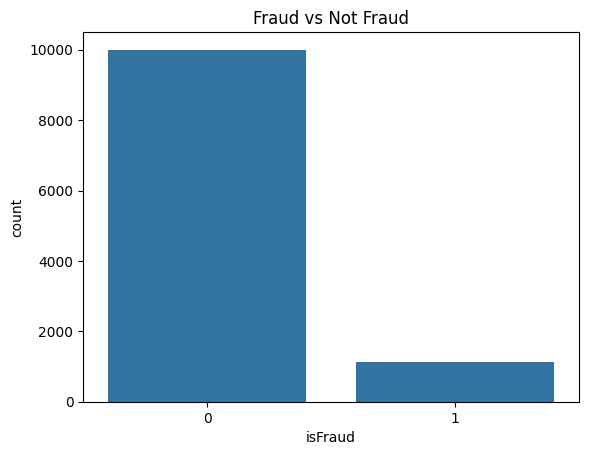

In [8]:
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Not Fraud")
plt.show()

# 5. Correlation heatmap

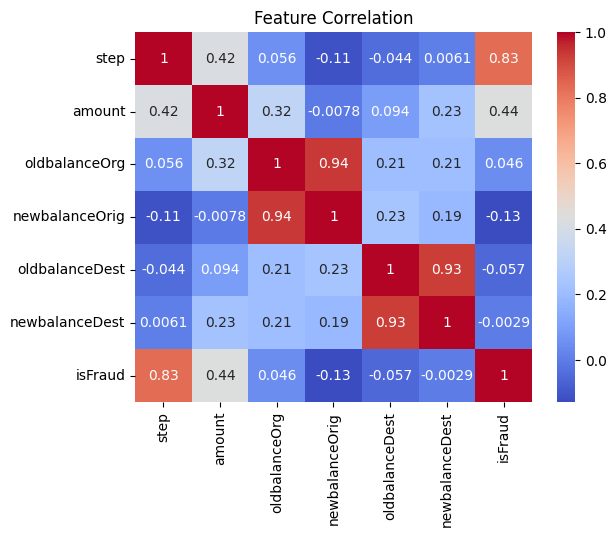

In [9]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# 6. Prepare data

In [10]:

df = pd.get_dummies(df, drop_first=True)
X = df.drop("isFraud", axis=1)
y = df["isFraud"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
# Drop highly correlated and less useful balance features
X = X.drop(columns=["newbalanceOrig", "newbalanceDest"])

# 7. Handle imbalance using SMOTE

In [ ]:
X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)

# 8. Train



In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)

    results.append([name, acc, prec, rec])

    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc,3))
    print("Precision:", round(prec,3))
    print("Recall:", round(rec,3))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression ===
Accuracy: 0.989
Precision: 0.959
Recall: 0.934

=== Random Forest ===
Accuracy: 0.995
Precision: 1.0
Recall: 0.952

=== Gradient Boosting ===
Accuracy: 0.991
Precision: 1.0
Recall: 0.912


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=None,          # let it grow fully (you can tune this)
    class_weight="balanced", # handle class imbalance
    random_state=42          # reproducibility
)

# Train the model
rf_model.fit(X_train_sm, y_train_sm)

RandomForestClassifier(class_weight='balanced', random_state=42)

# 9. Predict

In [ ]:
# 🔹 Predictions
y_pred  = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]  # probabilities for ROC

# 🔹 Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print("=== Random Forest Evaluation ===")
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")

=== Random Forest Evaluation ===
Accuracy: 0.996
Precision: 1.000
Recall: 0.956


# 10. Evaluation

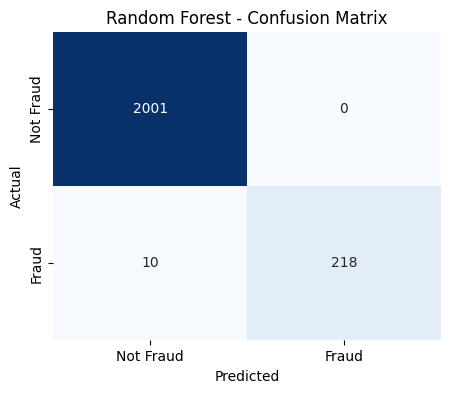

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 11. ROC Curve

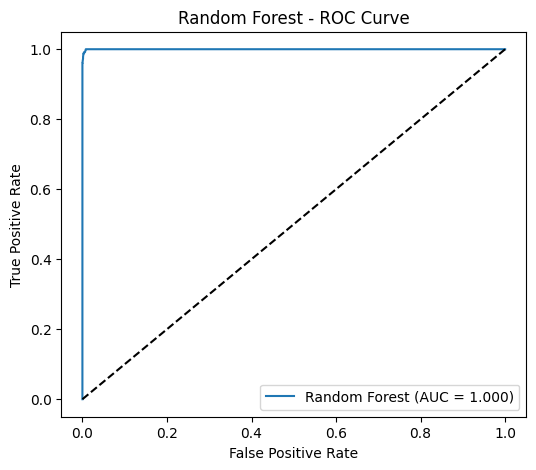

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.legend(loc="lower right")
plt.show()

#HYPERPARAMETER TUNING

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    "n_estimators": [25, 30, 40],     # number of trees
    "max_depth": [None, 2, 5, 10],     # depth of trees
    "min_samples_split": [2, 3, 5],     # min samples to split a node
    "class_weight": ["balanced"]         # handle imbalance
}

In [ ]:
# Initialize model
rf = RandomForestClassifier(random_state=42)

In [ ]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="roc_auc",   # better metric for fraud detection
    cv=3,
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid_search.fit(X_train_sm, y_train_sm)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'],
                         'max_depth': [None, 2, 5, 10],
                         'min_samples_split': [2, 3, 5],
                         'n_estimators': [25, 30, 40]},
             scoring='roc_auc', verbose=2)

In [ ]:
# Best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC Score:", grid_search.best_score_)

Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 3, 'n_estimators': 30}
Best ROC-AUC Score: 0.9999991327040609
